M1-M4 are the assumed models. M1-M12 are observation data-generating processes.

DeepSet, `S=D`, 10 observations. Use the previously trained 20d/10n networks.
Sparse OOD data: for M5-M12, only the first `1` dimensions follow the source-model setting; the remaining dimensions follow M1.
This notebook uses l_inf summary distance by default and writes to a sparse-specific result directory.


In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 10
num_datasets = 50
num_samples = 1000
n_ref = 2000

# Change this to 5 for the five-dimensional sparse misspecification experiment.
sparse_dims = 1
sparse_indices = np.arange(sparse_dims)
sparse_sources = tuple(f"m{i}" for i in range(5, 13))
distance_metric = "linf"

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_tag = f"20d_10n_sparse{sparse_dims}_{distance_metric}"
result_dir = project_dir / "results" / f"ood_{result_tag}"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},
    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1.0},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1.0},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
base_spec = source_specs["m1"]

print("result_dir:", result_dir)
print("sparse_dims:", sparse_dims)
print("sparse_sources:", sparse_sources)

result_dir: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/ood_20d_10n_sparse1_linf
sparse_dims: 1
sparse_sources: ('m5', 'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12')


In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [4]:
def generate_normal_dataset(spec, num_dims, num_obs, rng):
    mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
    x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
    return mu, x


def generate_sparse_source_dataset(source, source_spec, rng):
    """Generate one 20d dataset whose sparse dimensions follow source_spec and the rest follow M1."""
    mu, x = generate_normal_dataset(base_spec, num_dims, num_obs, rng)
    if source in sparse_sources:
        sparse_mu, sparse_x = generate_normal_dataset(source_spec, sparse_dims, num_obs, rng)
        mu = mu.copy()
        x = x.copy()
        mu[sparse_indices] = sparse_mu
        x[:, sparse_indices] = sparse_x
    return mu, x


# Generate sparse test datasets. M1-M4 remain the usual full-model datasets.
# For M5-M12, only the first sparse_dims dimensions are misspecified; all other dimensions follow M1.
datasets = {}
for source, spec in source_specs.items():
    data = []
    for dataset_id in range(num_datasets):
        mu, x = generate_sparse_source_dataset(source, spec, RNG)
        data.append({
            "mu": mu,
            "x": x,
            "id": dataset_id,
            "source_model": source,
            "sparse_dims": sparse_dims if source in sparse_sources else num_dims,
            "sparse_indices": sparse_indices.tolist() if source in sparse_sources else list(range(num_dims)),
            "sparse_ood": source in sparse_sources,
        })
    datasets[source] = data
    save_pickle(data, dataset_dir / f"{source}_raw.pkl")

print(datasets["m1"][0].keys())
print("M5 sparse indices:", datasets["m5"][0]["sparse_indices"])

dict_keys(['mu', 'x', 'id', 'source_model', 'sparse_dims', 'sparse_indices', 'sparse_ood'])
M5 sparse indices: [0]


In [5]:
datasets = {source: load_pickle(dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [6]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_20d_10n.keras"
filepath_m2 = network_dir / "m2_s_20d_10n.keras"
filepath_m3 = network_dir / "m3_s_20d_10n.keras"
filepath_m4 = network_dir / "m4_s_20d_10n.keras"
filepath_direct = network_dir / "direct_s_20d_10n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [7]:
# Compute logmls and PMPs
calculation_m1 = Calculation(approximator=approximator_m1,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m1",)
calculation_m2 = Calculation(approximator=approximator_m2,mu_prior_mean=3.0,mu_prior_std=1.0,
    num_dims=num_dims,num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m2",)
calculation_m3 = Calculation(approximator=approximator_m3,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=3.0,num_samples=num_samples,assumed_model="m3",)
calculation_m4 = Calculation(approximator=approximator_m4,mu_prior_mean=0.1,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m4",)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3, "m4": calculation_m4}

In [8]:
# compute logmls and PMPs for all datasets
datasets = sd.compute_logml_and_posteriors(datasets, calculations)
datasets = sd.compute_model_probabilities(datasets, approximator_direct)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model', 'sparse_dims', 'sparse_indices', 'sparse_ood', 'gold_log_marginal_m1', 'gold_post_samples_m1', 'npe_post_samples_m1', 'npe_log_marginal_m1', 'npe_log_marginal_gp_m1', 'gold_log_marginal_m2', 'gold_post_samples_m2', 'npe_post_samples_m2', 'npe_log_marginal_m2', 'npe_log_marginal_gp_m2', 'gold_log_marginal_m3', 'gold_post_samples_m3', 'npe_post_samples_m3', 'npe_log_marginal_m3', 'npe_log_marginal_gp_m3', 'gold_log_marginal_m4', 'gold_post_samples_m4', 'npe_post_samples_m4', 'npe_log_marginal_m4', 'npe_log_marginal_gp_m4', 'p_direct', 'p_gold', 'p_npe'])


In [9]:
# Load already computed logmls and PMPs for this sparse experiment.
datasets = {
    source: load_pickle(dataset_dir / f"{source}_logml_pmp.pkl")
    for source in sd.SOURCE_MODELS
}

In [10]:
# Fit summary-space reference distributions under the assumed models.
# These simulators stay unchanged because the neural networks and assumed models are unchanged.
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS)
}
references = sd.fit_summary_references(
    approximators,
    simulators,
    n_ref=n_ref,
    distance_metric=distance_metric,
    alpha=0.1,
)

pd.DataFrame({
    k: {
        "metric": v["distance_metric"],
        "summary_dim": v["summary_dim"],
        "dm_low": v["dm_low"],
        "dm_high": v["dm_high"],
        "median": v["median"],
    }
    for k, v in references.items()
}).T

,metric,summary_dim,dm_low,dm_high,median
m1,linf,20,0.575688,1.289715,0.856881
m2,linf,20,0.561481,1.282927,0.845903
m3,linf,20,0.594859,1.198333,0.835614
m4,linf,20,0.557155,1.284136,0.842962


In [11]:
# Add dynamic distance regimes and x(y) score.
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / f"posterior_distance_frame_{result_tag}.csv", index=False)
logml_df.to_csv(result_dir / f"logml_distance_frame_{result_tag}.csv", index=False)
pmp_df.to_csv(result_dir / f"pmp_ambiguity_frame_{result_tag}.csv", index=False)
logml_summary.to_csv(result_dir / f"logml_summary_{result_tag}.csv", index=False)
pmp_summary.to_csv(result_dir / f"pmp_summary_{result_tag}.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_{result_tag}.pkl")

In [12]:
# Load sparse datasets for plotting.
datasets = {
    source: load_pickle(dataset_dir / f"{source}_processed_{result_tag}.pkl")
    for source in sd.SOURCE_MODELS
}
posterior_df = pd.read_csv(result_dir / f"posterior_distance_frame_{result_tag}.csv")
logml_df = pd.read_csv(result_dir / f"logml_distance_frame_{result_tag}.csv")
pmp_df = pd.read_csv(result_dir / f"pmp_ambiguity_frame_{result_tag}.csv")

## Plots

In [ ]:
# signed logml error with shared y-axis
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

In [ ]:
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,distance_metric="linf",)

In [18]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

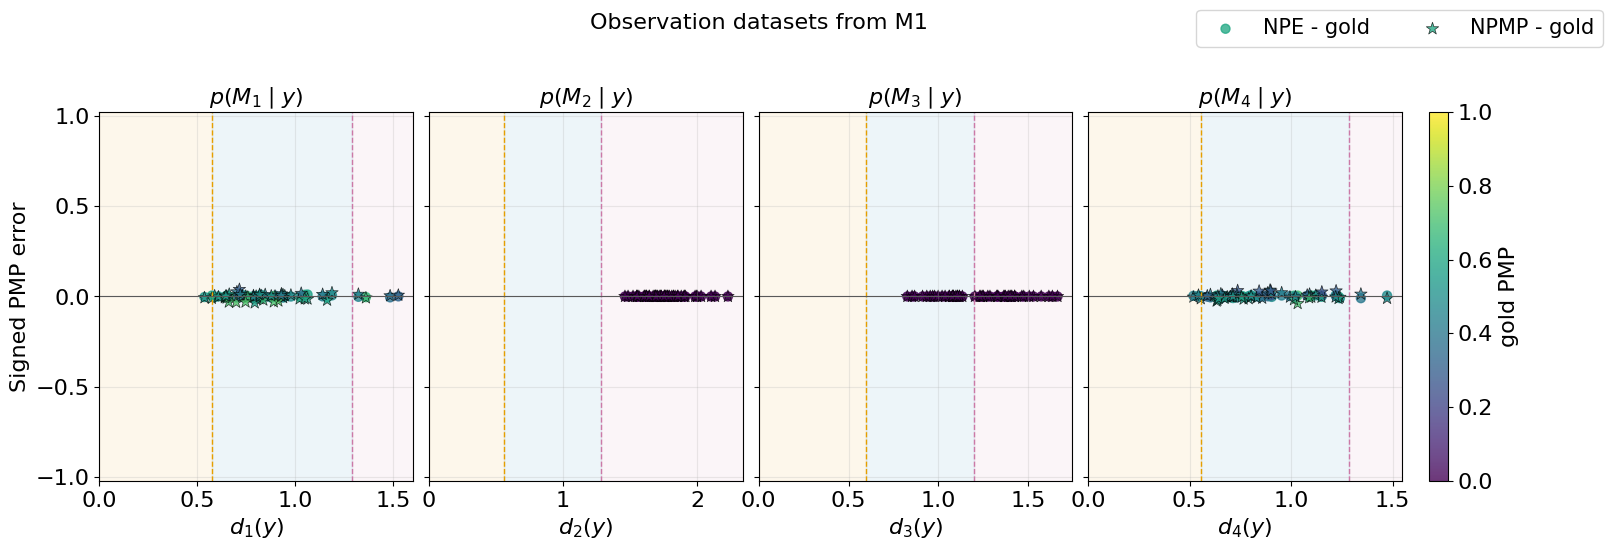

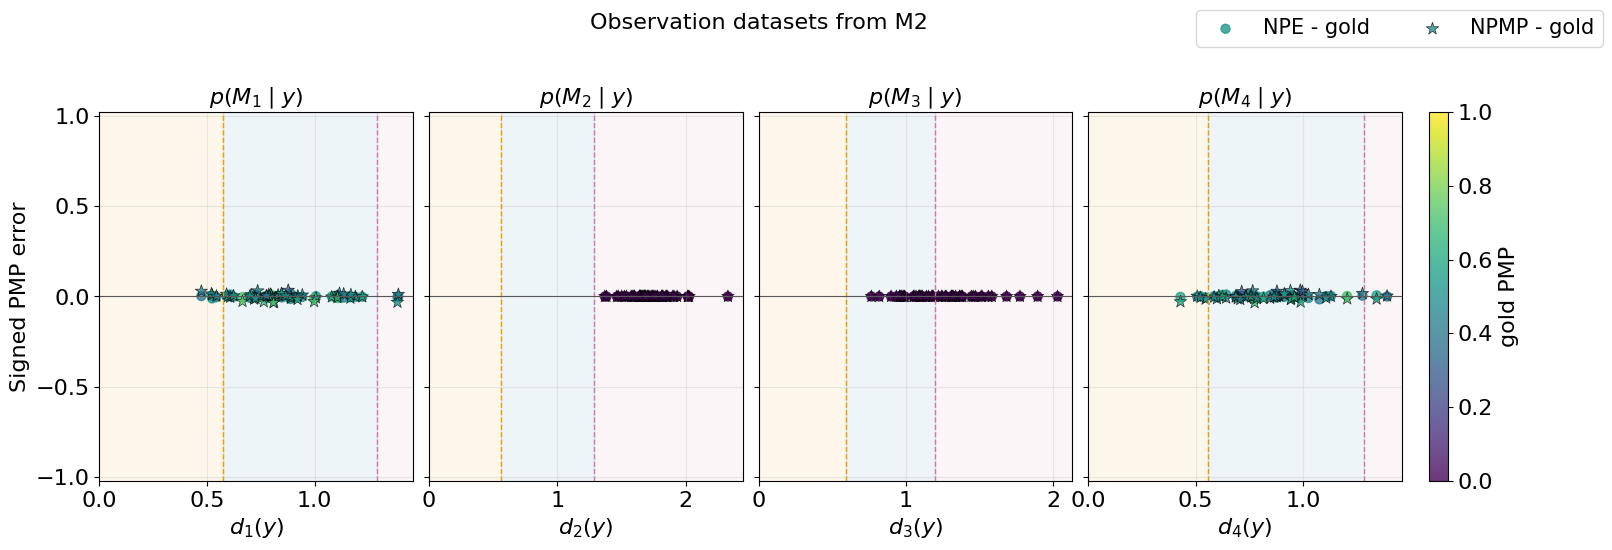

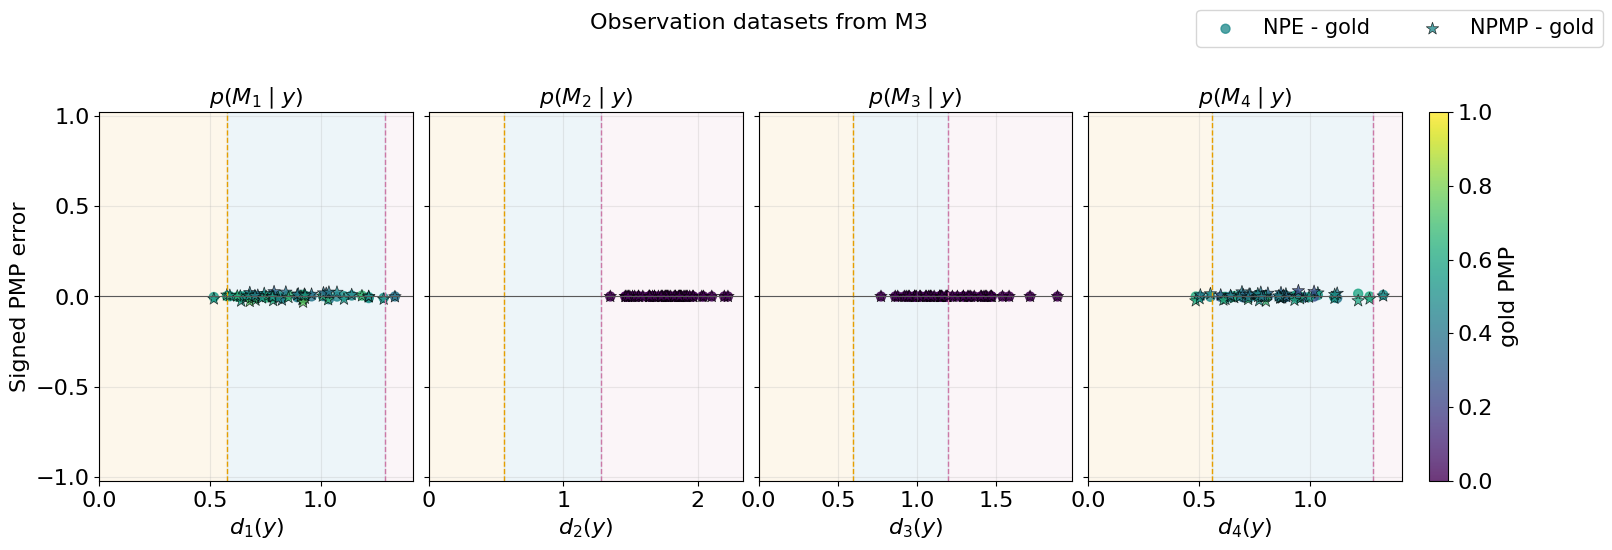

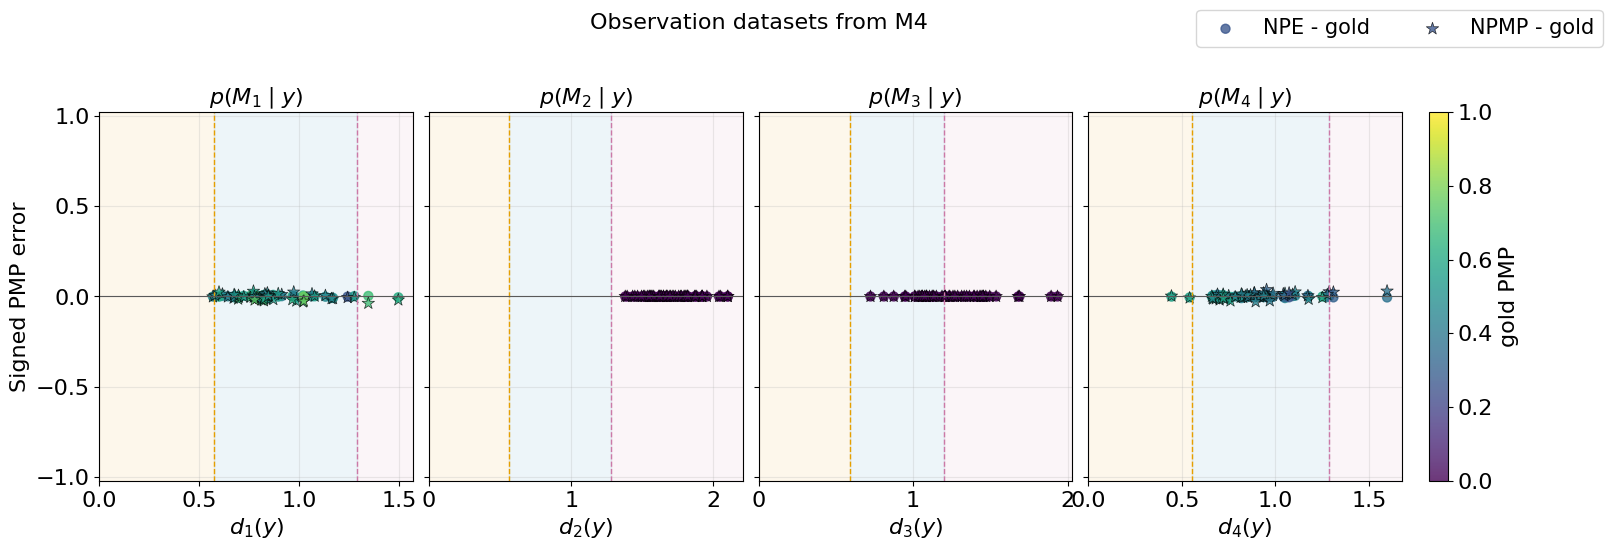

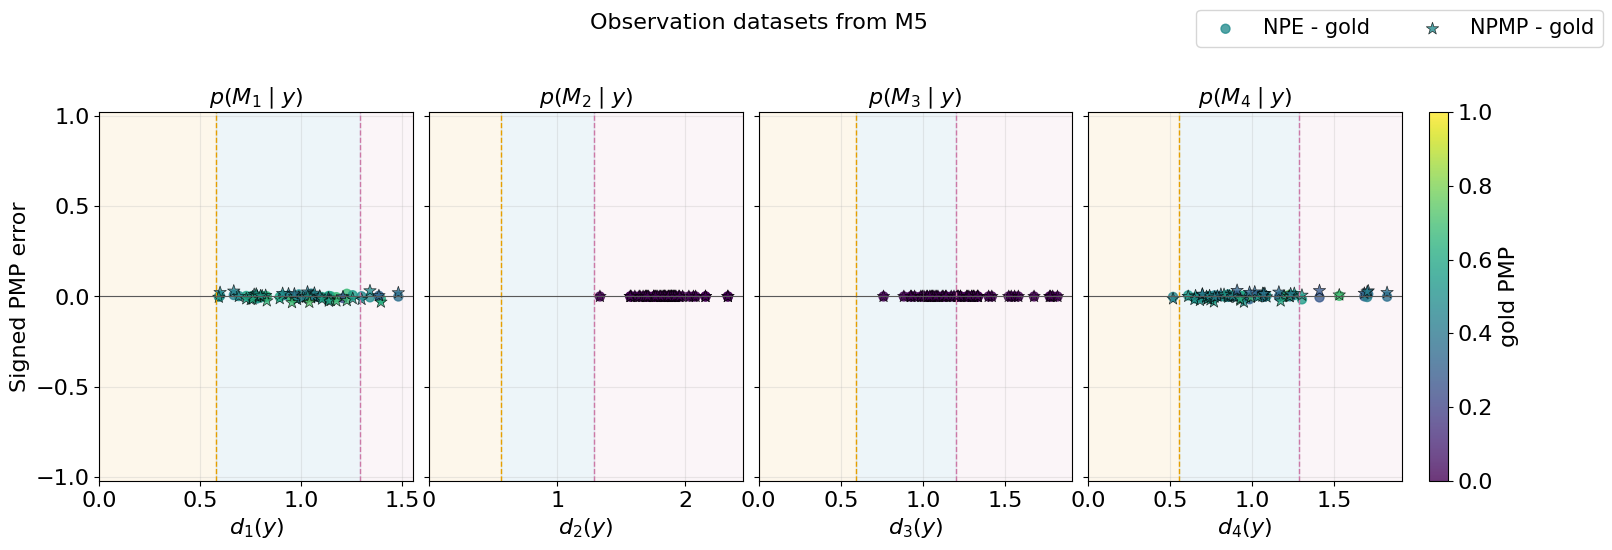

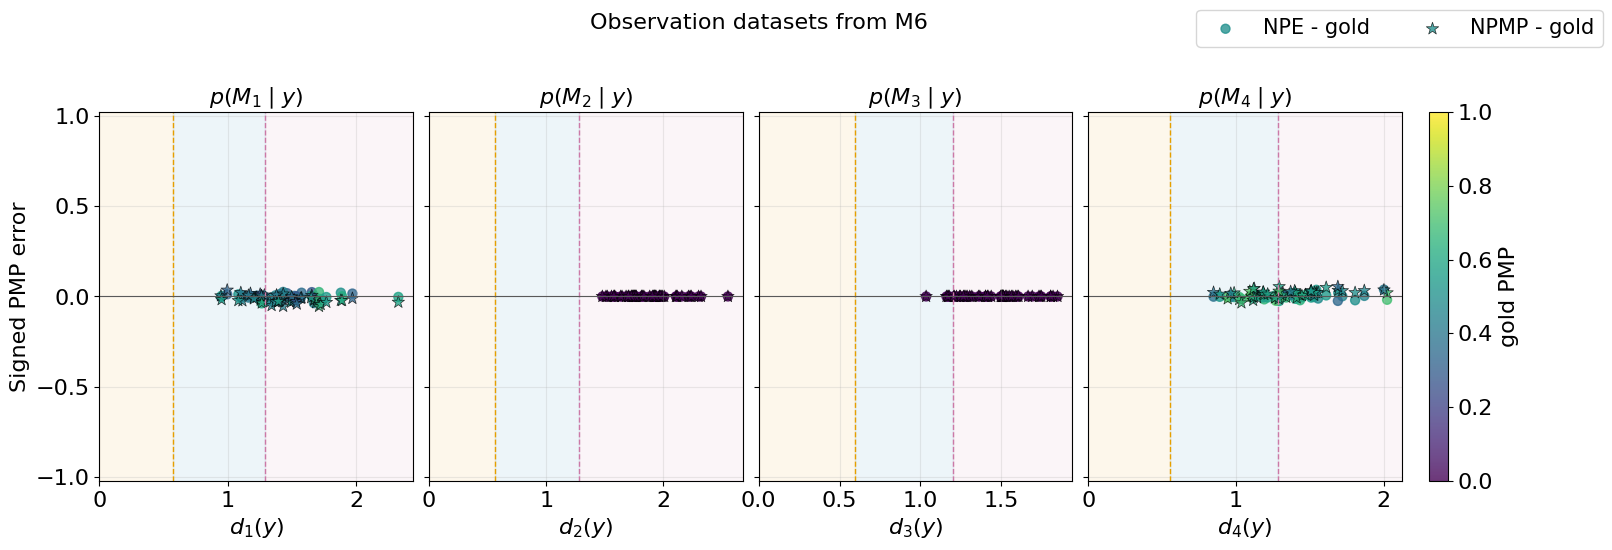

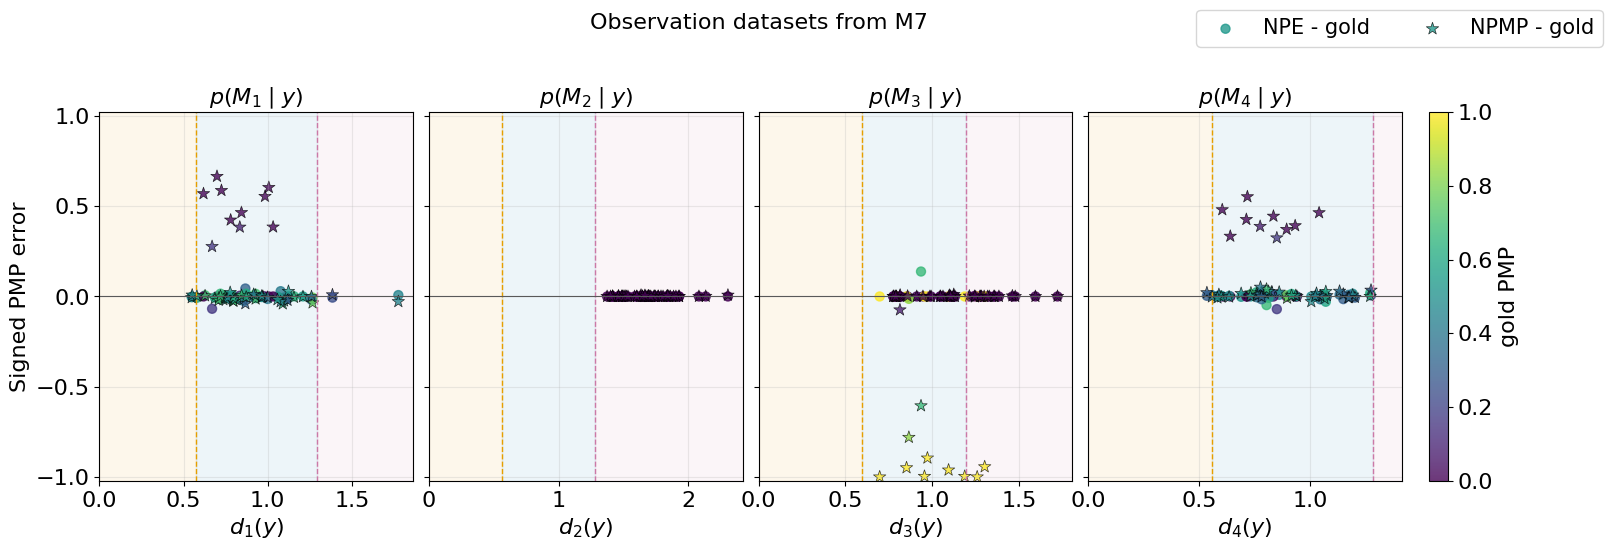

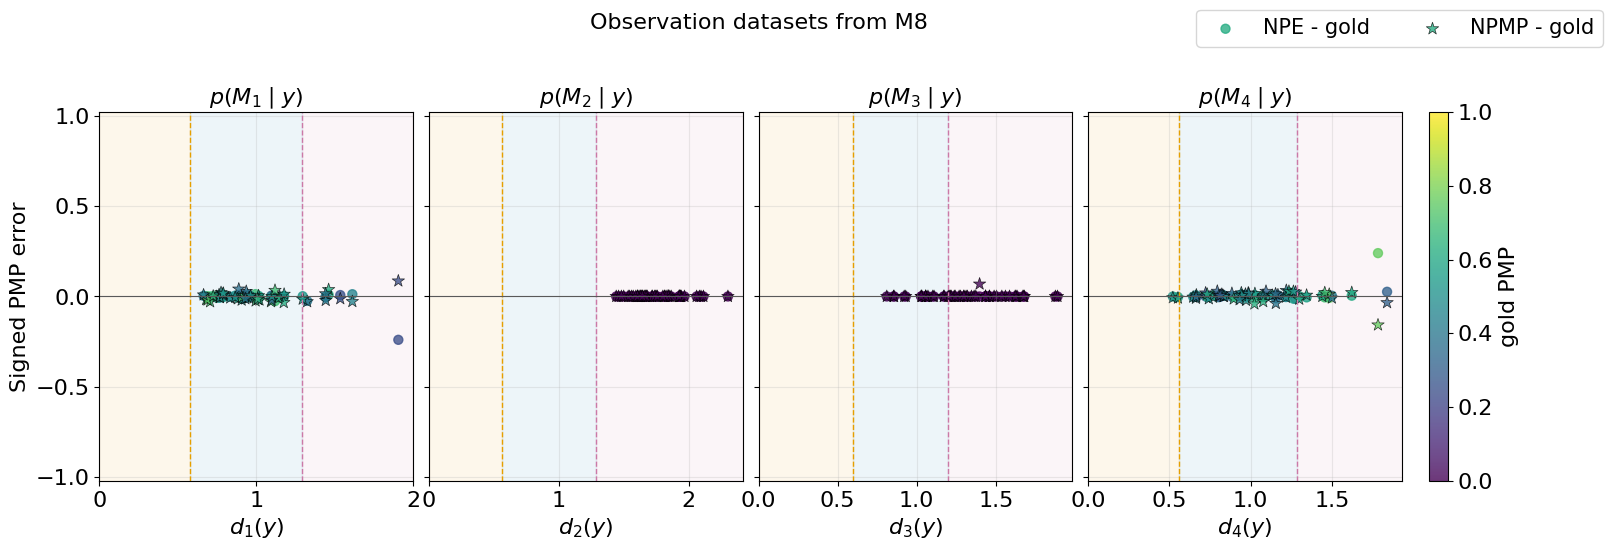

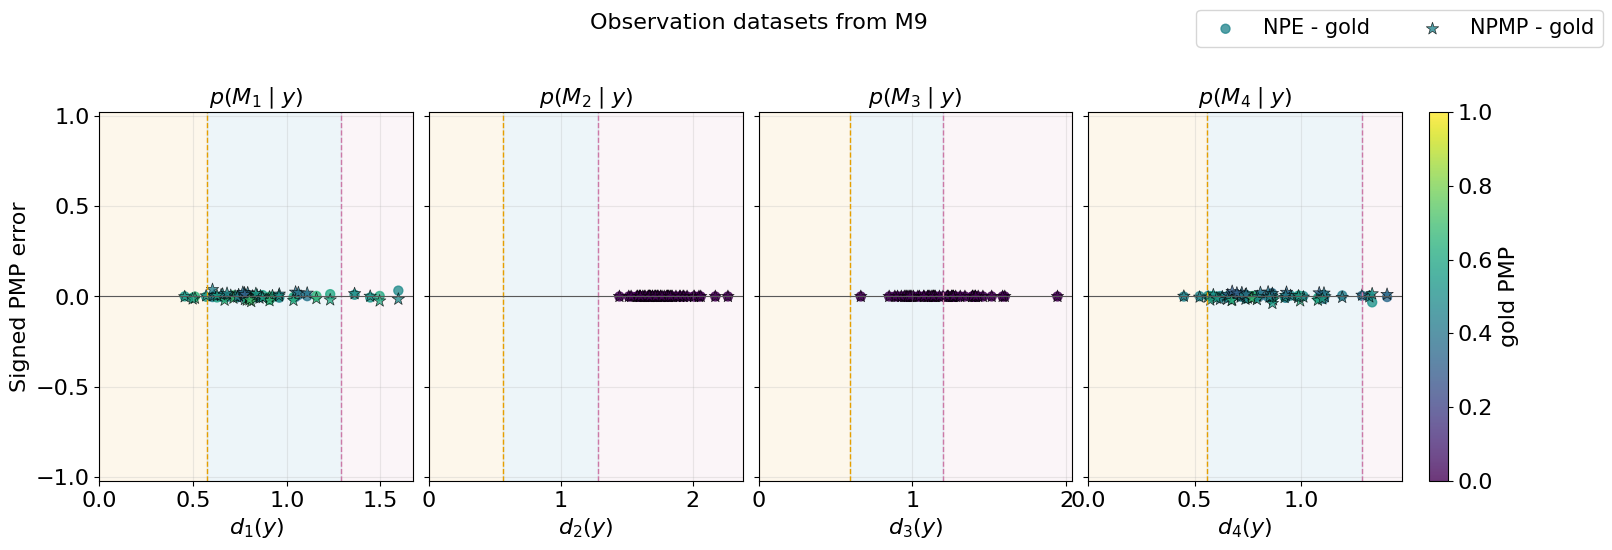

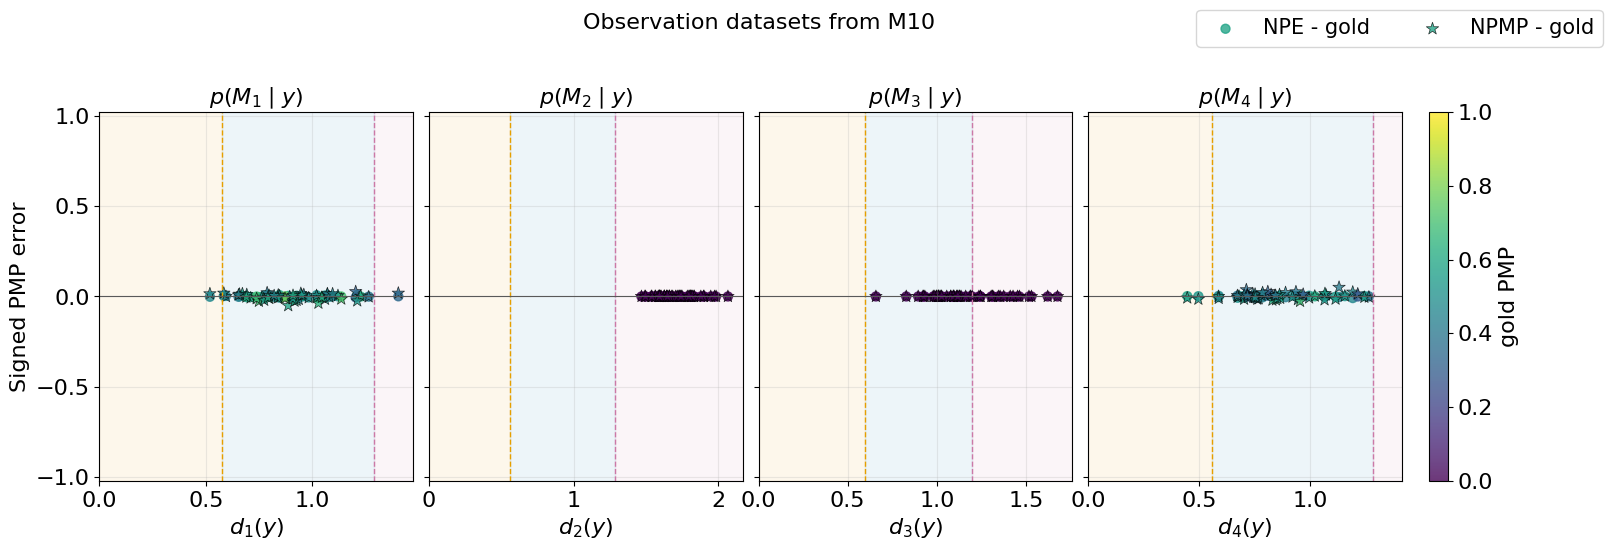

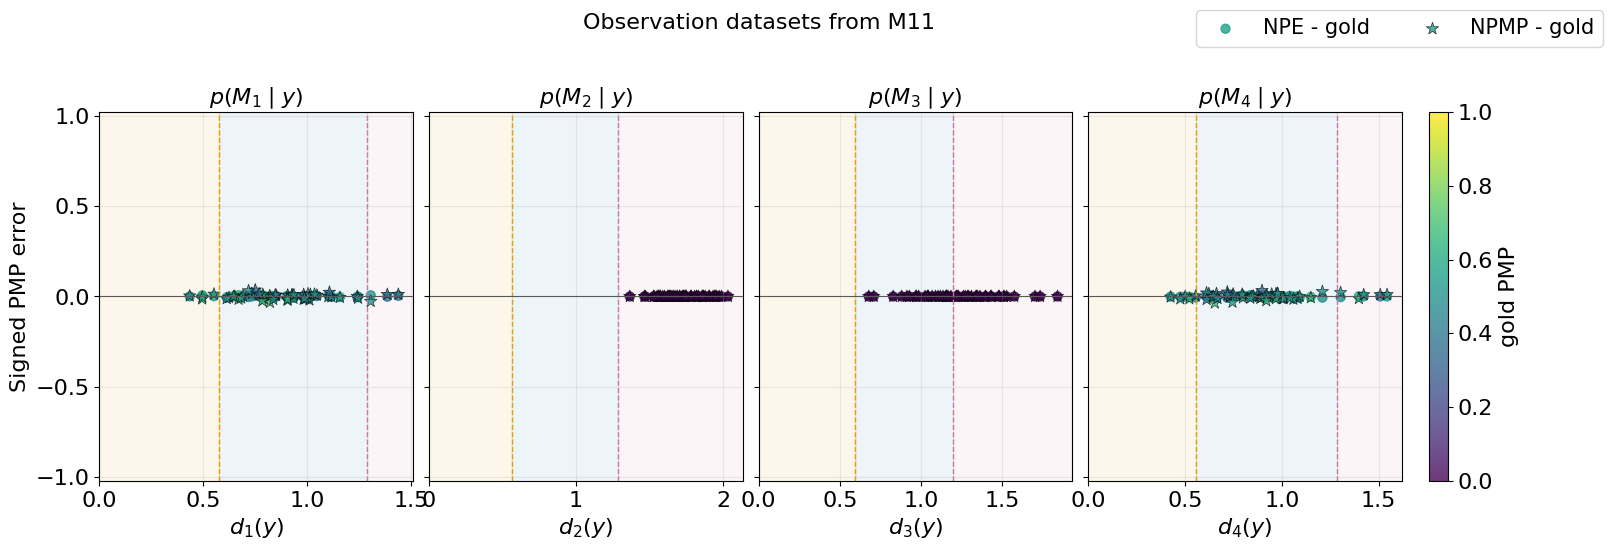

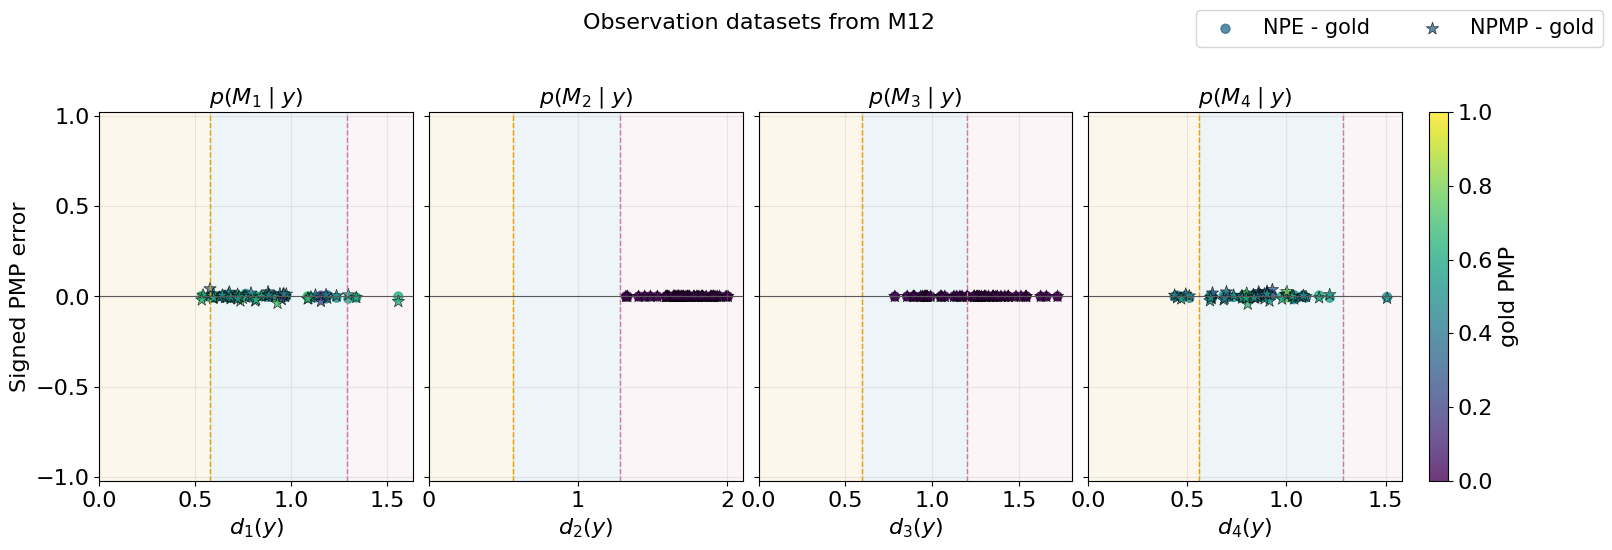

In [19]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)